In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, log_loss
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./datasets/titanic.csv")

In [3]:
df = df[['Fare', 'Age', 'Sex', 'Pclass', 'Survived']]
df.head()

,Fare,Age,Sex,Pclass,Survived
0,7.2500,22.0,male,3,0
1,71.2833,38.0,female,1,1
2,7.9250,26.0,female,3,1
3,53.1000,35.0,female,1,1
4,8.0500,35.0,male,3,0


In [4]:
df.isna().sum()

Fare         0
Age         30
Sex          0
Pclass       0
Survived     0
dtype: int64

array([[<Axes: title={'center': 'Fare'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Pclass'}>,
        <Axes: title={'center': 'Survived'}>]], dtype=object)

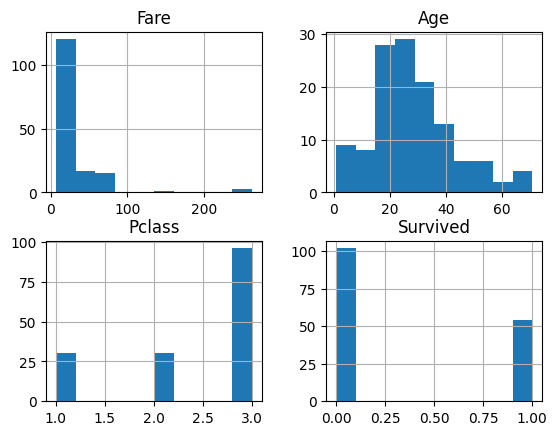

In [5]:
df.hist()

In [6]:
X = df[['Fare', 'Age', 'Sex', 'Pclass']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

In [7]:
num_attribs = ['Fare', 'Age', 'Pclass']
cat_attribs = ["Sex"]

num_pipeline = make_pipeline(
    SimpleImputer(strategy="mean"), 
    StandardScaler())

cat_pipeline = make_pipeline(
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

preprocessing

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [8]:
log_reg = make_pipeline(preprocessing, LogisticRegression())

scores = cross_val_score(
    log_reg,
    X_train,
    y_train,
    cv=3,              # 5-fold cross validation
    scoring="accuracy" # or f1, roc_auc, precision, recall, etc.
)

print(scores)
print("Mean accuracy:", scores.mean())
print("Std:", scores.std())

[0.78378378 0.77777778 0.80555556]
Mean accuracy: 0.789039039039039
Std: 0.01193355257013651


In [9]:
log_reg.fit(X_train, y_train)
print(f"model acc: {log_reg.score(X_test, y_test)}")

model acc: 0.8085106382978723


In [10]:
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

In [11]:
def plot_conf_matrix(y, y_pred):
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
    plt.rc('font', size=9)
    ConfusionMatrixDisplay.from_predictions(y, y_pred, ax=axs[0])
    axs[0].set_title("Confusion matrix")
    plt.rc('font', size=10)
    ConfusionMatrixDisplay.from_predictions(y, y_pred, ax=axs[1],
                                            normalize="true", values_format=".0%")
    axs[1].set_title("CM normalized by row")
    
    plt.show()

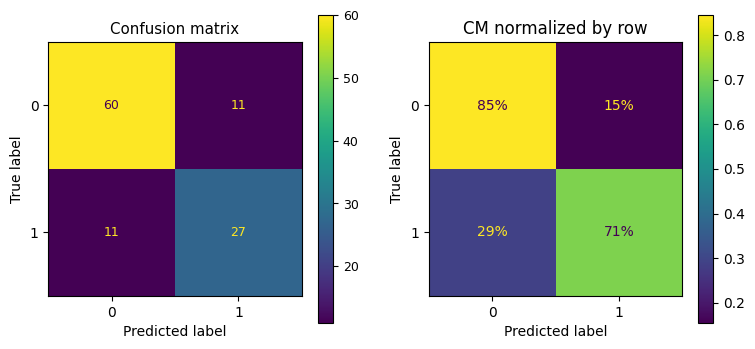

In [12]:
plot_conf_matrix(y_train, y_train_pred)

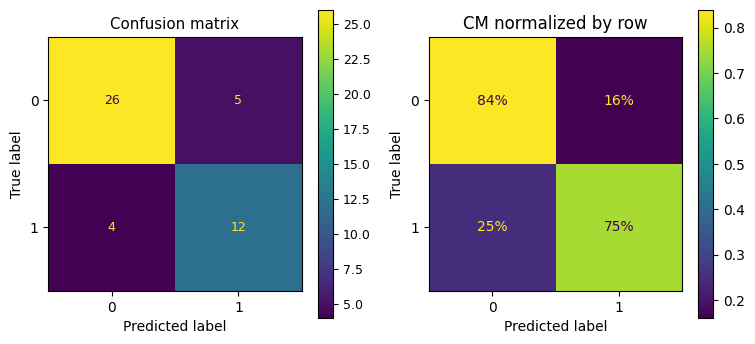

In [13]:
plot_conf_matrix(y_test, y_test_pred)

In [14]:
y[y == 0].shape[0] / len(y), y[y == 1].shape[0] / len(y)

(0.6538461538461539, 0.34615384615384615)

# We have less class 1 samples in comparison to class 0, so works poorly on class 1

In [17]:
model = log_reg[1]

feature_importance = pd.DataFrame(
    {
        "importance": model.coef_[0]
    },
    index=log_reg.named_steps["columntransformer"].get_feature_names_out()
).sort_values(by="importance", ascending=False)

feature_importance

,importance
cat__Sex_female,1.168683
num__Age,-0.256281
num__Fare,-0.304403
num__Pclass,-0.526666
cat__Sex_male,-1.168136


# Sex has greate influence. Because they sacrifices their lives to rescue women and children.
# Age has negative value. Cause children has priority.


In [75]:
compare = y_test_pred == y_test
true_predict = np.where(compare)[0][0]
true_predict

np.int64(0)

In [76]:
wrong_predict = np.where(~compare)[0][0]
wrong_predict

np.int64(2)

In [93]:
true_prob = log_reg.predict_proba(X_test.iloc[[true_predict]])
true_prob.shape

(1, 2)

In [94]:
wrong_prob = log_reg.predict_proba(X_test.iloc[[wrong_predict]])
wrong_prob.shape

(1, 2)

In [98]:
[y_test.iloc[true_predict]], true_prob

([np.int64(0)], array([[0.84049902, 0.15950098]]))

In [103]:
true_pred_loss = log_loss([y_test.iloc[true_predict]], true_prob, labels=[0, 1])
print(f"For true label {y_test.iloc[true_predict]} log loss is: {true_pred_loss}")
print(f"true prob: {true_prob}")

For true label 0 log loss is: 0.1737594967581975
true prob: [[0.84049902 0.15950098]]


In [104]:
wrong_pred_loss = log_loss([y_test.iloc[wrong_predict]], wrong_prob, labels=[0, 1])
print(f"For wrong label {y_test.iloc[wrong_predict]} log loss is: {wrong_pred_loss}")
print(f"wrong prob: {wrong_prob}")

For wrong label 0 log loss is: 1.0810735638170603
wrong prob: [[0.33923114 0.66076886]]


In [105]:
assert true_pred_loss < wrong_pred_loss # Wrong prediction has great loss value